# Important Libraries

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset and analyse class imbalance: what percentage of transactions are fraudulent?

In [54]:
df=pd.read_csv(r"C:\Users\kd940\Downloads\archive (1)\creditcard.csv")
df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [55]:
df.shape

(284807, 31)

In [56]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

In [57]:
df['Class'].unique()

array([0, 1])

In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [59]:
df.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [60]:
class_counts = df['Class'].value_counts()
print(class_counts)

Class
0    284315
1       492
Name: count, dtype: int64


In [61]:
class_percentage = df['Class'].value_counts(normalize=True) * 100
print(class_percentage)

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


### There are 99.82 % Legitimate Transactions
### There are 0.17 % Fradulent Transactions

#  EDA: distribution of transaction amounts for fraud vs. non-fraud; time-of-day analysis


([<matplotlib.axis.XTick at 0x1ed846b96d0>,
 [Text(0, 0, 'Legitimate (0)'), Text(1, 0, 'Fraud (1)')])

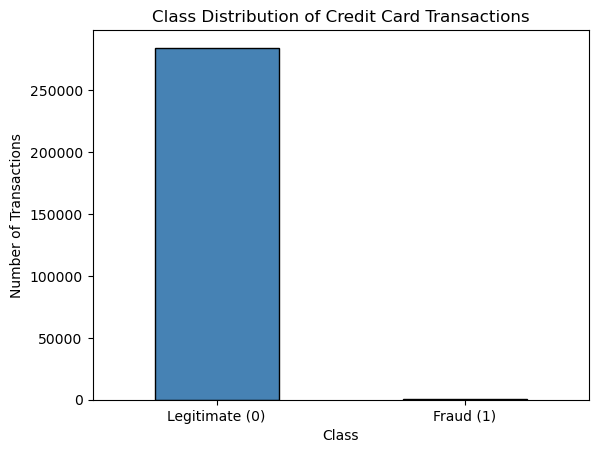

In [62]:
class_counts.plot(kind='bar', color=['steelblue', 'red'], edgecolor='black')

plt.title("Class Distribution of Credit Card Transactions")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1], ['Legitimate (0)', 'Fraud (1)'], rotation=0)

##### The class distribution plot reveals a severe class imbalance, with legitimate transactions accounting for almost all observations and fraudulent transactions representing only a very small fraction of the dataset. Such an imbalance can bias machine learning models toward predicting the majority class, making Precision, Recall, F1-Score, and ROC-AUC more appropriate evaluation metrics than accuracy alone.

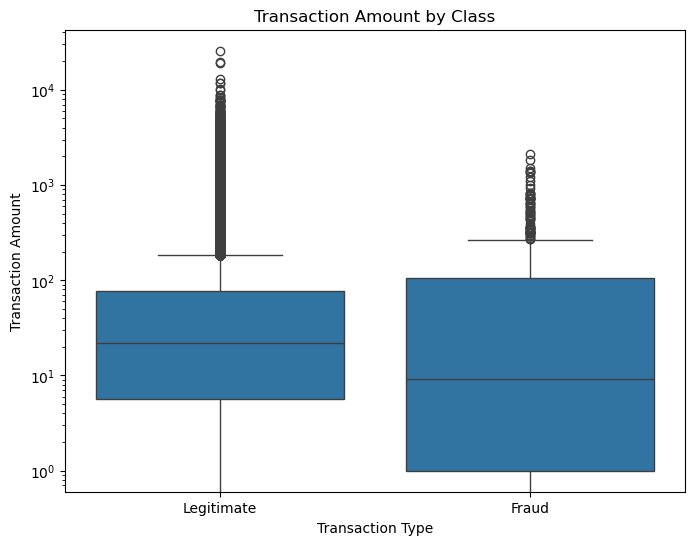

In [63]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Class', y='Amount', data=df)
plt.yscale('log')
plt.xticks([0,1], ['Legitimate', 'Fraud'])
plt.title("Transaction Amount by Class")
plt.xlabel("Transaction Type")
plt.ylabel("Transaction Amount")

plt.show()

## Interpretation
#### The boxplot (on a logarithmic scale) shows that both legitimate and fraudulent transactions are concentrated at relatively low transaction amounts, with several high-value outliers present in each class. Legitimate transactions exhibit a wider range of extreme transaction amounts, while the overlapping distributions indicate that transaction amount alone cannot effectively distinguish fraudulent transactions from legitimate ones.

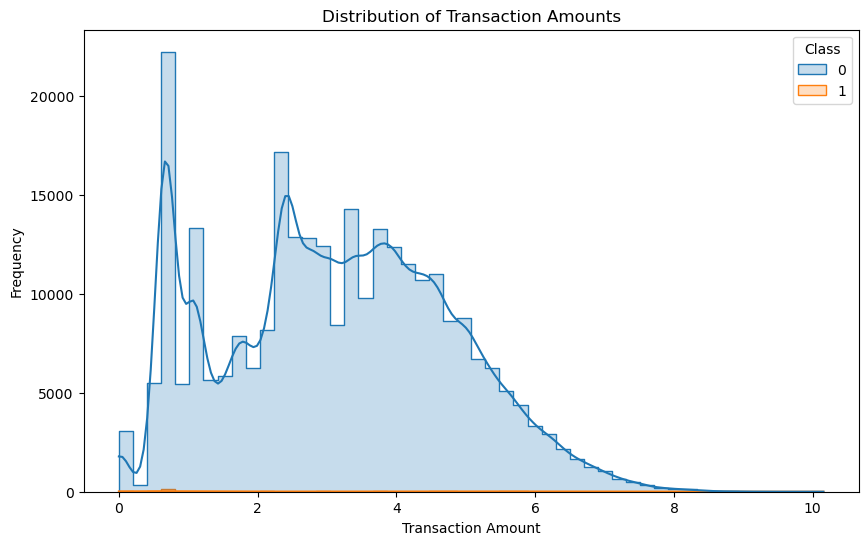

In [64]:
plt.figure(figsize=(10,6))
df['LogAmount'] = np.log1p(df['Amount'])
sns.histplot(
    data=df,
    x='LogAmount',
    hue='Class',
    bins=50,
    kde=True,
    element='step'
)
# plt.xlim(0,1000)
plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

## Interpretation: 
#### The distribution shows that most transactions occur at lower transaction amounts, while the frequency decreases as the transaction amount increases, indicating a right-skewed distribution. Legitimate transactions dominate the plot because they constitute the vast majority of the dataset, whereas fraudulent transactions are barely visible due to the severe class imbalance. The overlapping distributions suggest that transaction amount alone is not sufficient to distinguish fraudulent transactions, highlighting the need to use additional features for accurate fraud detection.

In [65]:
# Convert seconds into hour of the day
df['Hour'] = (df['Time'] / 3600) % 24

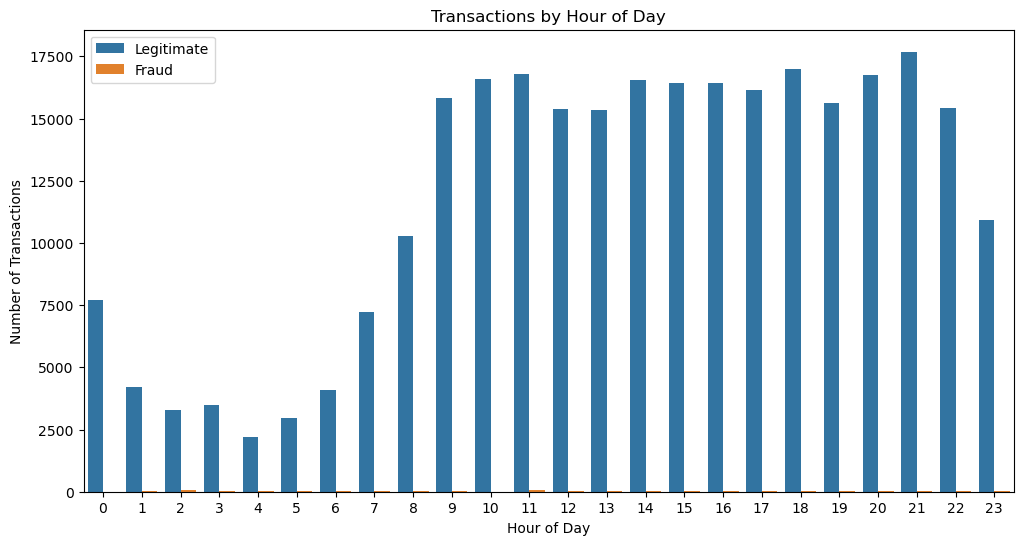

In [66]:
plt.figure(figsize=(12,6))

sns.countplot(
    x=df['Hour'].astype(int),
    hue=df['Class']
)

plt.title("Transactions by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")
plt.legend(['Legitimate', 'Fraud'])

plt.show()

#### The number of legitimate transactions varies throughout the day, with transaction activity increasing during daytime and evening hours and decreasing during the early morning hours. Fraudulent transactions occur across all hours but remain significantly fewer than legitimate transactions because of the severe class imbalance. This indicates that while transaction volume changes over the day, time of day alone is not a strong indicator of fraudulent activity and should be combined with other features for effective fraud detection.

In [67]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,LogAmount,Hour
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,5.014760,0.000000
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,1.305626,0.000000
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,5.939276,0.000278
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,4.824306,0.000278
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,4.262539,0.000556


# Discuss why standard accuracy is a misleading metric for imbalanced fraud datasets.

##### The Credit Card Fraud Detection dataset is extremely imbalanced, with only 0.1727% fraudulent transactions. A model that predicts every transaction as legitimate would achieve approximately 99.83% accuracy but would detect no fraudulent transactions. Therefore, accuracy is a misleading metric for this problem. Metrics such as Precision, Recall, F1-Score and the Confusion Matrix provide a more reliable evaluation of fraud detection performance.

# Train/test split (ensure fraud cases appear in both splits using stratification)

In [68]:
X = df.drop(columns=["Time","Class"])
y = df['Class']

In [69]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

# Apply a class imbalance handling technique: SMOTE oversampling, undersampling, or class_weight='balanced'


In [70]:
from imblearn.over_sampling import SMOTE 
smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

In [71]:
print("After SMOTE:")
print(y_train_smote.value_counts())

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


#  Train at least 2 models: Logistic Regression + one of (Decision Tree, Random Forest, or XGBoost)

# Evaluate using: Precision, Recall, F1-Score, and AUC-ROC curve (not just accuracy)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report,confusion_matrix,precision_score,recall_score,f1_score,roc_auc_score,RocCurveDisplay)


In [73]:
lr = LogisticRegression(random_state=42,max_iter=1000)

lr.fit(x_train_smote, y_train_smote)

lr_pred = lr.predict(x_test)
lr_prob = lr.predict_proba(x_test)[:,1]

c:\Users\kd940\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [75]:
print("Logistic Regression")

print(classification_report(y_test, lr_pred))

print("Precision :", precision_score(y_test, lr_pred))
print("Recall    :", recall_score(y_test, lr_pred))
print("F1 Score  :", f1_score(y_test, lr_pred))
print("ROC-AUC   :", roc_auc_score(y_test, lr_prob))

Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.08      0.91      0.14        98

    accuracy                           0.98     56962
   macro avg       0.54      0.94      0.57     56962
weighted avg       1.00      0.98      0.99     56962

Precision : 0.07679033649698015
Recall    : 0.9081632653061225
F1 Score  : 0.14160700079554495
ROC-AUC   : 0.9728557503474095


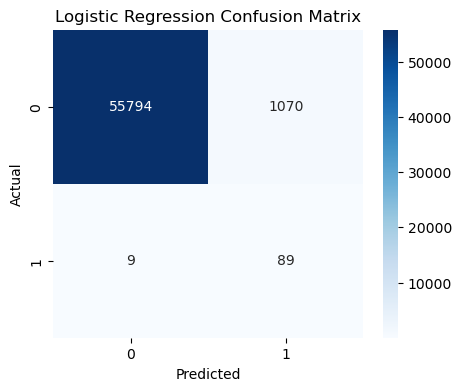

In [84]:
import seaborn as sns

plt.figure(figsize=(5,4))

sns.heatmap(
    confusion_matrix(y_test, lr_pred),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

##### The Logistic Regression model correctly classified 55,794 legitimate transactions (True Negatives) and 89 fraudulent transactions (True Positives). It incorrectly classified 1,070 legitimate transactions as fraudulent (False Positives), resulting in a relatively high number of false alarms. On the other hand, it missed only 9 fraudulent transactions (False Negatives), demonstrating a high Recall and the ability to detect most fraud cases. Although the model is effective at identifying fraudulent transactions, its large number of false positives reduces its Precision, which may lead to unnecessary investigations of legitimate transactions. Therefore, while Logistic Regression is suitable when maximizing fraud detection is the priority, it is less practical than Random Forest due to its higher false positive rate.

In [79]:
rf = RandomForestClassifier( n_estimators=50,random_state=42,n_jobs=-1)

rf.fit(x_train_smote, y_train_smote)

rf_pred = rf.predict(x_test)
rf_prob = rf.predict_proba(x_test)[:,1]

In [80]:
print("Random Forest")

print(classification_report(y_test, rf_pred))

print("Precision :", precision_score(y_test, rf_pred))
print("Recall    :", recall_score(y_test, rf_pred))
print("F1 Score  :", f1_score(y_test, rf_pred))
print("ROC-AUC   :", roc_auc_score(y_test, rf_prob))

Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.88      0.86      0.87        98

    accuracy                           1.00     56962
   macro avg       0.94      0.93      0.93     56962
weighted avg       1.00      1.00      1.00     56962

Precision : 0.875
Recall    : 0.8571428571428571
F1 Score  : 0.865979381443299
ROC-AUC   : 0.9703807257990423


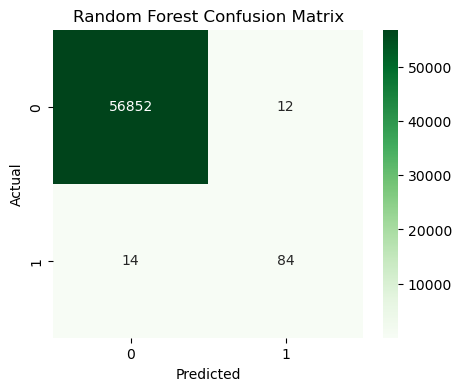

In [81]:
plt.figure(figsize=(5,4))

sns.heatmap(
    confusion_matrix(y_test, rf_pred),
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

##### The Random Forest model correctly classified 56,852 legitimate transactions (True Negatives) and 84 fraudulent transactions (True Positives), demonstrating strong overall performance. It incorrectly classified only 12 legitimate transactions as fraud (False Positives), indicating a very low false alarm rate. However, the model missed 14 fraudulent transactions (False Negatives), meaning a small number of fraud cases were not detected. The high number of correct predictions and the low number of misclassifications indicate that the model effectively distinguishes between legitimate and fraudulent transactions. Overall, the confusion matrix confirms that the Random Forest model achieves an excellent balance between fraud detection and minimizing false alerts, making it well-suited for real-world credit

<Figure size 800x600 with 0 Axes>

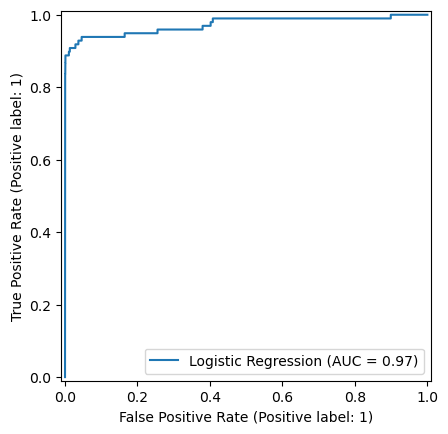

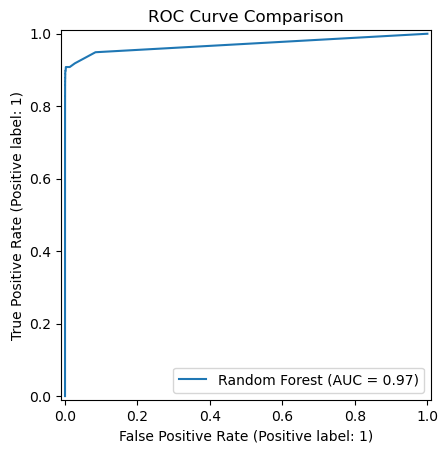

In [82]:
plt.figure(figsize=(8,6))

RocCurveDisplay.from_predictions(
    y_test,
    lr_prob,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    rf_prob,
    name="Random Forest"
)

plt.title("ROC Curve Comparison")

plt.show()

## Comparison: 
##### Both Logistic Regression and Random Forest achieved excellent ROC-AUC values (~0.97), indicating that both models effectively distinguish fraudulent transactions from legitimate ones. Since their ROC curves are very similar, their overall ranking ability is comparable. However, ROC-AUC alone does not capture the trade-off between false positives and false negatives in an imbalanced dataset. When combined with the evaluation metrics, Random Forest is the better-performing model because it maintains a much higher Precision and F1-Score while achieving nearly the same Recall and ROC-AUC as Logistic Regression. Therefore, Random Forest is the preferred model for deployment, as it provides a better balance between detecting fraud and minimizing unnecessary false alarms.

In [83]:
import pandas as pd

results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest"
    ],

    "Precision":[
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred)
    ],

    "Recall":[
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred)
    ],

    "F1-Score":[
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred)
    ],

    "ROC-AUC":[
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob)
    ]

})

results = results.round(3)

print(results)

                 Model  Precision  Recall  F1-Score  ROC-AUC
0  Logistic Regression      0.077   0.908     0.142    0.973
1        Random Forest      0.875   0.857     0.866    0.970


## Conclusion

The Logistic Regression model achieved a very high Recall (0.908), meaning it correctly identified 90.8% of fraudulent transactions. However, its Precision is only 0.077, indicating that only 7.7% of the transactions predicted as fraud were actually fraudulent. This results in a very low F1-Score (0.142), suggesting that the model generates a large number of false positives, which could lead to unnecessary investigations and inconvenience for legitimate customers. Despite having a high ROC-AUC (0.973), its low precision makes it less practical for deployment.

The Random Forest model achieved a Precision of 0.875 and a Recall of 0.857, indicating that it correctly detects 85.7% of fraudulent transactions while maintaining a very low false positive rate. Its F1-Score of 0.866 demonstrates an excellent balance between precision and recall. Although its ROC-AUC (0.970) is slightly lower than Logistic Regression, the difference is very small and does not outweigh its much stronger precision and F1-score.

# Explain which metric matters most for fraud detection and why (Recall vs. Precision trade-off)

##### In credit card fraud detection, Recall and Precision are more important evaluation metrics than accuracy because fraudulent transactions represent only a very small proportion of all transactions. These two metrics measure different aspects of the model's performance.

##### Recall measures the percentage of actual fraudulent transactions that are correctly detected by the model. Precision measures the percentage of transactions predicted as fraudulent that are actually fraudulent.

##### The choice between Recall and Precision depends on the business objective. In fraud detection, Recall is generally the most important metric because failing to detect a fraudulent transaction (False Negative) can result in direct financial losses, reputational damage, and reduced customer trust. A model with high recall identifies most fraudulent transactions, even if it also flags some legitimate transactions as suspicious.

##### However, maximizing Recall often reduces Precision, leading to more False Positives, where legitimate transactions are incorrectly classified as fraud. Although this may inconvenience customers by requiring additional verification, it is usually less costly than allowing fraudulent transactions to go undetected.

##### Therefore, an effective fraud detection system should aim for high Recall while maintaining a reasonable Precision. The F1-Score is useful because it balances both metrics, and the ROC-AUC provides an overall measure of the model's ability to distinguish between fraudulent and legitimate transactions across different decision thresholds.

# Feature importance or coefficient analysis

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

   Feature  Importance
13     V14    0.195626
3       V4    0.129471
9      V10    0.114604
10     V11    0.106697
16     V17    0.086510
11     V12    0.071724
2       V3    0.035460
6       V7    0.034472
15     V16    0.033671
1       V2    0.025466


# Discuss scalability: how would this model handle 1 million transactions per hour?

### Scalability Analysis

The trained fraud detection model can be scaled to process 1 million transactions per hour, but its real-world performance depends on the choice of algorithm, computational resources, and deployment architecture.

Among the evaluated models, Random Forest achieved the best overall performance, with a Precision of 0.875, Recall of 0.857, and F1-Score of 0.866, making it the preferred model for fraud detection. However, Random Forest requires more computational resources during prediction because each transaction must be evaluated across multiple decision trees. In contrast, Logistic Regression makes predictions much faster and is more computationally efficient, although its very low precision (0.077) means it generates many false fraud alerts despite its high recall (0.908).

To handle 1 million transactions per hour (approximately 278 transactions per second), the deployed system should use:

Distributed or cloud-based infrastructure to process requests in parallel.
Load balancing to distribute incoming transactions across multiple servers.
Batch or streaming frameworks (e.g., Apache Kafka or Apache Spark Streaming) for real-time transaction processing.
Optimized hardware with multi-core CPUs or GPUs, depending on the model complexity.
Model monitoring and periodic retraining to adapt to evolving fraud patterns.

Overall, the Random Forest model is suitable for deployment because it provides a strong balance between fraud detection capability and false alarm reduction. With adequate computational resources and a scalable deployment architecture, it can efficiently support high-volume transaction environments.